# 09. 2025년 서울 ASOS 날씨 데이터 정제

기상청 ASOS 시간자료 CSV를 모델링에 사용할 수 있도록 정제한다.

## 목적

- 원본 CSV의 한글 깨짐 문제 해결
- `cp949` 인코딩으로 안전하게 로드
- 컬럼명을 모델링용 영문 컬럼명으로 표준화
- 강수량/적설량 결측값을 0으로 처리
- 날짜·시간 파생변수 생성
- 악천후 여부 플래그 생성
- UTF-8 기반 정제 CSV 저장

## 원본 파일

`data/raw/OBS_ASOS_TIM_20260912192544.csv`

이 파일은 UTF-8이 아니라 `cp949` 계열 인코딩으로 저장되어 있어, 기본 UTF-8로 읽으면 한글 컬럼명과 지점명이 깨질 수 있다.

In [8]:
from pathlib import Path
import platform
import unicodedata

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 100)

# 한글 폰트 설정
if platform.system() == "Darwin":
    plt.rcParams["font.family"] = "AppleGothic"
elif platform.system() == "Windows":
    plt.rcParams["font.family"] = "Malgun Gothic"
else:
    plt.rcParams["font.family"] = "NanumGothic"

plt.rcParams["axes.unicode_minus"] = False

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

RAW_PATH = PROJECT_ROOT / "data" / "raw" / "OBS_ASOS_TIM_20260912192544.csv"
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
OUTPUT_PATH = PROCESSED_DIR / "weather_asos_seoul_2025_hourly_clean.csv"

print("PROJECT_ROOT:", PROJECT_ROOT)
print("RAW_PATH:", RAW_PATH)
print("OUTPUT_PATH:", OUTPUT_PATH)

PROJECT_ROOT: /Users/blaumonde/calltaxi-DA
RAW_PATH: /Users/blaumonde/calltaxi-DA/data/raw/OBS_ASOS_TIM_20260912192544.csv
OUTPUT_PATH: /Users/blaumonde/calltaxi-DA/data/processed/weather_asos_seoul_2025_hourly_clean.csv


## 1. 원본 CSV 로드

원본 파일은 `cp949` 인코딩으로 읽는다.

`강수량`, `적설`, `3시간신적설`의 빈 값은 관측 누락이라기보다 해당 시간에 강수/적설이 없다는 의미로 해석할 수 있으므로, 모델링용 정제 단계에서 0으로 채운다.

In [2]:
raw_weather = pd.read_csv(
    RAW_PATH,
    encoding="cp949",
    low_memory=False,
)

print("raw shape:", raw_weather.shape)
display(raw_weather.head())
display(raw_weather.dtypes.to_frame("dtype"))

raw shape: (8760, 8)


,지점,지점명,일시,기온(°C),강수량(mm),풍속(m/s),적설(cm),3시간신적설(cm)
0,108,서울,2025-01-01 00:00,-1.2,NaN,0.7,NaN,NaN
1,108,서울,2025-01-01 01:00,-1.7,NaN,1.1,NaN,NaN
2,108,서울,2025-01-01 02:00,-1.8,NaN,0.5,NaN,NaN
3,108,서울,2025-01-01 03:00,-2.0,NaN,1.9,NaN,NaN
4,108,서울,2025-01-01 04:00,-2.3,NaN,2.2,NaN,NaN


,dtype
지점,int64
지점명,str
일시,str
기온(°C),float64
강수량(mm),float64
풍속(m/s),float64
적설(cm),float64
3시간신적설(cm),float64


## 2. 컬럼명 표준화

원본 컬럼을 모델링에서 쓰기 쉬운 영문 컬럼명으로 바꾼다.

| 원본 컬럼 | 정제 컬럼 | 의미 |
|---|---|---|
| `지점` | `station_id` | 기상 관측소 ID |
| `지점명` | `station_name` | 기상 관측소명 |
| `일시` | `datetime` | 관측 일시 |
| `기온(°C)` | `temperature_c` | 기온, 섭씨 |
| `강수량(mm)` | `precipitation_mm` | 시간 강수량 |
| `풍속(m/s)` | `wind_speed_ms` | 풍속 |
| `적설(cm)` | `snow_depth_cm` | 적설 깊이 |
| `3시간신적설(cm)` | `new_snow_3h_cm` | 최근 3시간 신적설 |

In [3]:
COLUMN_RENAME_MAP = {
    "지점": "station_id",
    "지점명": "station_name",
    "일시": "datetime",
    "기온(°C)": "temperature_c",
    "강수량(mm)": "precipitation_mm",
    "풍속(m/s)": "wind_speed_ms",
    "적설(cm)": "snow_depth_cm",
    "3시간신적설(cm)": "new_snow_3h_cm",
}

weather = raw_weather.rename(columns=COLUMN_RENAME_MAP).copy()

weather["datetime"] = pd.to_datetime(weather["datetime"], errors="coerce")

numeric_cols = [
    "temperature_c",
    "precipitation_mm",
    "wind_speed_ms",
    "snow_depth_cm",
    "new_snow_3h_cm",
]

for col in numeric_cols:
    weather[col] = pd.to_numeric(weather[col], errors="coerce")

# 강수/적설 관련 결측은 관측값이 비어 있는 경우가 많아 0으로 처리
zero_fill_cols = [
    "precipitation_mm",
    "snow_depth_cm",
    "new_snow_3h_cm",
]
weather[zero_fill_cols] = weather[zero_fill_cols].fillna(0)

# 기온/풍속은 실제 결측 가능성이 있으므로 시간 순서 기준 보간 후 남은 값만 앞뒤 값으로 채움
weather = weather.sort_values("datetime").reset_index(drop=True)
weather[["temperature_c", "wind_speed_ms"]] = (
    weather[["temperature_c", "wind_speed_ms"]]
    .interpolate(method="linear", limit_direction="both")
)

print("clean shape:", weather.shape)
display(weather.head())
display(weather.isna().sum().to_frame("missing_count"))

clean shape: (8760, 8)


,station_id,station_name,datetime,temperature_c,precipitation_mm,wind_speed_ms,snow_depth_cm,new_snow_3h_cm
0,108,서울,2025-01-01 00:00:00,-1.2,0.0,0.7,0.0,0.0
1,108,서울,2025-01-01 01:00:00,-1.7,0.0,1.1,0.0,0.0
2,108,서울,2025-01-01 02:00:00,-1.8,0.0,0.5,0.0,0.0
3,108,서울,2025-01-01 03:00:00,-2.0,0.0,1.9,0.0,0.0
4,108,서울,2025-01-01 04:00:00,-2.3,0.0,2.2,0.0,0.0


,missing_count
station_id,0
station_name,0
datetime,0
temperature_c,0
precipitation_mm,0
wind_speed_ms,0
snow_depth_cm,0
new_snow_3h_cm,0


## 3. 모델링용 파생변수 생성

콜택시 대기시간 모델과 `접수일시` 기준으로 병합하기 위해 날짜/시간 컬럼을 만든다.

추가 생성 컬럼:

| 컬럼 | 의미 |
|---|---|
| `weather_date` | 관측 날짜 |
| `weather_hour` | 관측 시간대 |
| `month` | 월 |
| `dayofweek` | 요일, 월요일=0 |
| `is_rain` | 강수량이 0보다 큰 시간 |
| `is_snow` | 적설 또는 신적설이 0보다 큰 시간 |
| `is_freezing` | 기온이 0도 이하인 시간 |
| `is_cold_wave_like` | 기온이 -5도 이하인 한파성 시간 |
| `is_strong_wind` | 풍속이 5m/s 이상인 시간 |
| `is_bad_weather` | 비/눈/한파성/강풍 중 하나라도 해당되는 시간 |

In [4]:
weather["weather_date"] = weather["datetime"].dt.date
weather["weather_hour"] = weather["datetime"].dt.hour
weather["month"] = weather["datetime"].dt.month
weather["dayofweek"] = weather["datetime"].dt.dayofweek

weather["is_rain"] = (weather["precipitation_mm"] > 0).astype(int)
weather["is_snow"] = (
    (weather["snow_depth_cm"] > 0) |
    (weather["new_snow_3h_cm"] > 0)
).astype(int)
weather["is_freezing"] = (weather["temperature_c"] <= 0).astype(int)
weather["is_cold_wave_like"] = (weather["temperature_c"] <= -5).astype(int)
weather["is_strong_wind"] = (weather["wind_speed_ms"] >= 5).astype(int)
weather["is_bad_weather"] = (
    (weather["is_rain"] == 1) |
    (weather["is_snow"] == 1) |
    (weather["is_cold_wave_like"] == 1) |
    (weather["is_strong_wind"] == 1)
).astype(int)

model_weather_cols = [
    "datetime",
    "weather_date",
    "weather_hour",
    "station_id",
    "station_name",
    "temperature_c",
    "precipitation_mm",
    "wind_speed_ms",
    "snow_depth_cm",
    "new_snow_3h_cm",
    "month",
    "dayofweek",
    "is_rain",
    "is_snow",
    "is_freezing",
    "is_cold_wave_like",
    "is_strong_wind",
    "is_bad_weather",
]

weather_model = weather[model_weather_cols].copy()

print("model weather shape:", weather_model.shape)
display(weather_model.head())
display(weather_model.describe(include="all").T)

model weather shape: (8760, 18)


,datetime,weather_date,weather_hour,station_id,station_name,temperature_c,precipitation_mm,wind_speed_ms,snow_depth_cm,new_snow_3h_cm,month,dayofweek,is_rain,is_snow,is_freezing,is_cold_wave_like,is_strong_wind,is_bad_weather
0,2025-01-01 00:00:00,2025-01-01,0,108,서울,-1.2,0.0,0.7,0.0,0.0,1,2,0,0,1,0,0,0
1,2025-01-01 01:00:00,2025-01-01,1,108,서울,-1.7,0.0,1.1,0.0,0.0,1,2,0,0,1,0,0,0
2,2025-01-01 02:00:00,2025-01-01,2,108,서울,-1.8,0.0,0.5,0.0,0.0,1,2,0,0,1,0,0,0
3,2025-01-01 03:00:00,2025-01-01,3,108,서울,-2.0,0.0,1.9,0.0,0.0,1,2,0,0,1,0,0,0
4,2025-01-01 04:00:00,2025-01-01,4,108,서울,-2.3,0.0,2.2,0.0,0.0,1,2,0,0,1,0,0,0


,count,unique,top,freq,mean,min,25%,50%,75%,max,std
datetime,8760,NaN,NaN,NaN,2025-07-02 11:30:00,2025-01-01 00:00:00,2025-04-02 05:45:00,2025-07-02 11:30:00,2025-10-01 17:15:00,2025-12-31 23:00:00,NaN
weather_date,8760,365,2025-01-01,24,NaN,NaN,NaN,NaN,NaN,NaN,NaN
weather_hour,8760.0,NaN,NaN,NaN,11.5,0.0,5.75,11.5,17.25,23.0,6.922582
station_id,8760.0,NaN,NaN,NaN,108.0,108.0,108.0,108.0,108.0,108.0,0.0
station_name,8760,1,서울,8760,NaN,NaN,NaN,NaN,NaN,NaN,NaN
temperature_c,8760.0,NaN,NaN,NaN,14.143516,-12.1,4.5,15.0,23.9,37.6,11.293341
precipitation_mm,8760.0,NaN,NaN,NaN,0.180639,0.0,0.0,0.0,0.0,35.2,1.31748
wind_speed_ms,8760.0,NaN,NaN,NaN,2.338002,0.0,1.5,2.2,3.0,8.4,1.113466
snow_depth_cm,8760.0,NaN,NaN,NaN,0.079635,0.0,0.0,0.0,0.0,8.9,0.492282
new_snow_3h_cm,8760.0,NaN,NaN,NaN,0.004829,0.0,0.0,0.0,0.0,5.1,0.115855


## 4. 기본 분포 확인

날씨 변수의 대략적인 분포를 확인한다.

In [5]:
summary = pd.DataFrame({
    "rows": [len(weather_model)],
    "start_datetime": [weather_model["datetime"].min()],
    "end_datetime": [weather_model["datetime"].max()],
    "rain_hours": [weather_model["is_rain"].sum()],
    "snow_hours": [weather_model["is_snow"].sum()],
    "bad_weather_hours": [weather_model["is_bad_weather"].sum()],
})

display(summary)

,rows,start_datetime,end_datetime,rain_hours,snow_hours,bad_weather_hours
0,8760,2025-01-01,2025-12-31 23:00:00,666,393,1452


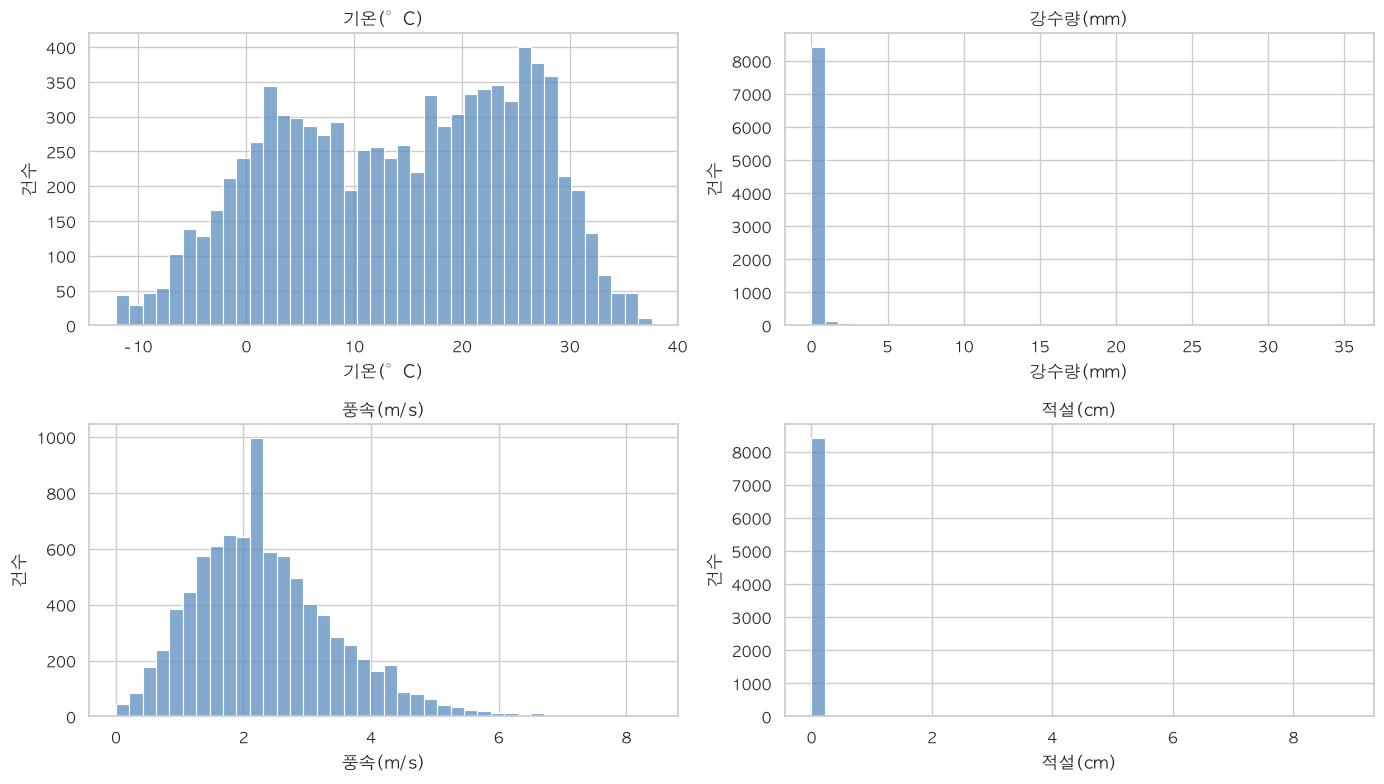

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
axes = axes.ravel()

plot_specs = [
    ("temperature_c", "기온(°C)"),
    ("precipitation_mm", "강수량(mm)"),
    ("wind_speed_ms", "풍속(m/s)"),
    ("snow_depth_cm", "적설(cm)"),
]

for ax, (col, title) in zip(axes, plot_specs):
    sns.histplot(weather_model[col], bins=40, ax=ax, color="#5B8CC0")
    ax.set_title(title)
    ax.set_xlabel(title)
    ax.set_ylabel("건수")

plt.tight_layout()
plt.show()

## 5. 정제 CSV 저장

한글 깨짐을 줄이기 위해 `utf-8-sig` 인코딩으로 저장한다.

모델링 노트북에서는 아래 파일을 `pd.read_csv(..., encoding="utf-8-sig")`로 읽으면 된다.

In [7]:
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

weather_model.to_csv(
    OUTPUT_PATH,
    index=False,
    encoding="utf-8-sig",
)

print("saved:", OUTPUT_PATH)
print("rows:", len(weather_model))
print("columns:", list(weather_model.columns))

saved: /Users/blaumonde/calltaxi-DA/data/processed/weather_asos_seoul_2025_hourly_clean.csv
rows: 8760
columns: ['datetime', 'weather_date', 'weather_hour', 'station_id', 'station_name', 'temperature_c', 'precipitation_mm', 'wind_speed_ms', 'snow_depth_cm', 'new_snow_3h_cm', 'month', 'dayofweek', 'is_rain', 'is_snow', 'is_freezing', 'is_cold_wave_like', 'is_strong_wind', 'is_bad_weather']


## 6. 모델링 데이터와 병합할 때 사용할 키

콜택시 모델링 데이터의 `접수일시`에서 날짜와 시간을 뽑아 날씨 데이터와 병합하면 된다.

```python
model_data["weather_date"] = model_data["접수일시"].dt.date
model_data["weather_hour"] = model_data["접수일시"].dt.hour

model_data = model_data.merge(
    weather_model,
    on=["weather_date", "weather_hour"],
    how="left",
)
```

주의: 날씨 데이터에도 `month`, `dayofweek`가 있으므로 기존 모델링 데이터의 동일 컬럼과 충돌하지 않게 필요하면 날씨 쪽 컬럼은 제외하거나 suffix를 지정한다.